# Valid Points Distributions

Some parameter values causes points with unitarity, perturbativity and postiivty of the potential, well behaved conditions

This notebook tries to find what comibination of parameter allows for that condition

In [2]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pickle

# Configuración inicial
folder_csv = "../outphys"

file_pattern = f"{folder_csv}/*.csv"  # Ajusta a tu carpeta

chunksize = 10000
target_col = "branching_ratio_h2_gaga"

param_cols = ['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12']


# Listar todos los archivos que cumplan con el patrón
files = glob.glob(file_pattern)
print("Número de archivos encontrados:", len(files))

Número de archivos encontrados: 13


In [3]:

# -----------------------
# Parte 2: Reservoir Sampling
# -----------------------
sample_size = 100000  # Tamaño de muestra deseado para visualización
reservoir = []       # Reservorio para almacenar registros
total_count = 0      # Contador global de filas procesadas

print("\n--- Ejecutando Reservoir Sampling ---")
for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            # Asegurarse de que el target exista y filtrar filas con NaN en el target
            if target_col not in chunk.columns:
                continue
            chunk = chunk.dropna(subset=[target_col])
            if chunk.empty:
                continue
            # Mezclar el chunk para romper el orden original
            chunk = chunk.sample(frac=1, random_state=42)
            # Convertir a lista de registros (solo columnas de parámetros y el target y flags)
            cols_to_keep = param_cols + [target_col, "positivity_ok", "unitarity_ok", "perturbativity_ok"]
            records = chunk[cols_to_keep].to_dict('records')
            for record in records:
                total_count += 1
                if len(reservoir) < sample_size:
                    reservoir.append(record)
                else:
                    s = random.randint(0, total_count - 1)
                    if s < sample_size:
                        reservoir[s] = record
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

if reservoir:
    sample_df = pd.DataFrame(reservoir)
    print(f"Muestra final para gráficos: {sample_df.shape[0]} registros.")
else:
    sample_df = pd.DataFrame(columns=param_cols + [target_col, "positivity_ok", "unitarity_ok", "perturbativity_ok"])
    print("No se obtuvo ninguna muestra.")



--- Ejecutando Reservoir Sampling ---
Muestra final para gráficos: 100000 registros.


In [4]:

# -----------------------
# Parte 3: Acumulación de histogramas para target_col en distintos grupos
# -----------------------
bins = 50
# Determinar globalmente el rango del target entre todos los archivos
global_min = np.inf
global_max = -np.inf
total_valid = 0

for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            if target_col not in chunk.columns:
                continue
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            valid = chunk[target_col].dropna()
            if not valid.empty:
                total_valid += len(valid)
                global_min = min(global_min, valid.min())
                global_max = max(global_max, valid.max())
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

print("\nEstadísticas globales para", target_col)
print("  Mínimo:", global_min)
print("  Máximo:", global_max)
print("  Total de valores válidos:", total_valid)

# Definir bin edges
bin_edges = np.linspace(global_min, global_max, bins + 1)

# Inicializar diccionario para contar histogramas de cada grupo
hist_dict = {
    "all": np.zeros(bins),
    "perturbativity_ok": np.zeros(bins),
    "unitarity_ok": np.zeros(bins),
    "positivity_ok": np.zeros(bins),
    "all_three": np.zeros(bins),
    "none": np.zeros(bins)
}

# Función para actualizar histograma dado un array de valores y un vector de bins
def update_hist(arr, bins, current_hist):
    counts, _ = np.histogram(arr, bins=bins)
    return current_hist + counts

# Segundo pase: Acumular histogramas para cada grupo
for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            if target_col not in chunk.columns:
                continue
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            # Considerar solo valores válidos
            valid = chunk[target_col].dropna()
            if valid.empty:
                continue
            # Grupo "all"
            hist_dict["all"] = update_hist(valid, bin_edges, hist_dict["all"])
            # Filtrar por cada condición
            for condition, key in [("perturbativity_ok", "perturbativity_ok"),
                                   ("unitarity_ok", "unitarity_ok"),
                                   ("positivity_ok", "positivity_ok")]:
                valid_cond = chunk[chunk[condition] == 1][target_col].dropna()
                if not valid_cond.empty:
                    hist_dict[key] = update_hist(valid_cond, bin_edges, hist_dict[key])
            # Grupo "all_three": donde las tres condiciones son 1
            cond_all = chunk[(chunk["perturbativity_ok"] == 1) & (chunk["unitarity_ok"] == 1) & (chunk["positivity_ok"] == 1)][target_col].dropna()
            if not cond_all.empty:
                hist_dict["all_three"] = update_hist(cond_all, bin_edges, hist_dict["all_three"])
            # Grupo "none": donde las tres condiciones son 0
            cond_none = chunk[(chunk["perturbativity_ok"] == 0) & (chunk["unitarity_ok"] == 0) & (chunk["positivity_ok"] == 0)][target_col].dropna()
            if not cond_none.empty:
                hist_dict["none"] = update_hist(cond_none, bin_edges, hist_dict["none"])
    except Exception as e:
        print(f"Error al procesar {f}: {e}")



Estadísticas globales para branching_ratio_h2_gaga
  Mínimo: 0.0
  Máximo: 0.913534311752936
  Total de valores válidos: 6487595


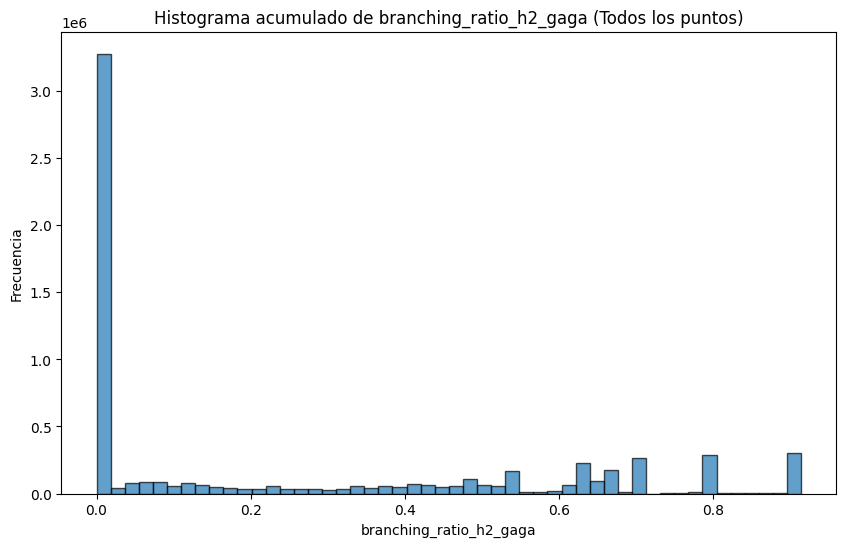

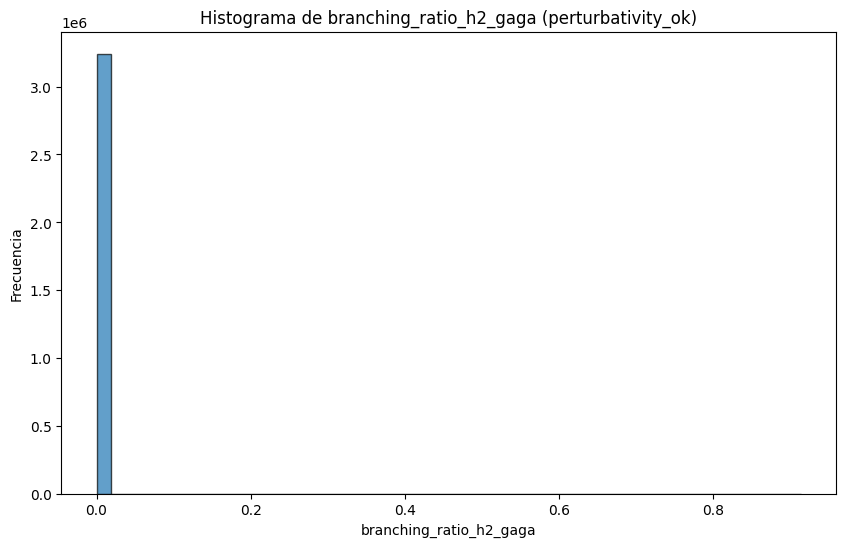

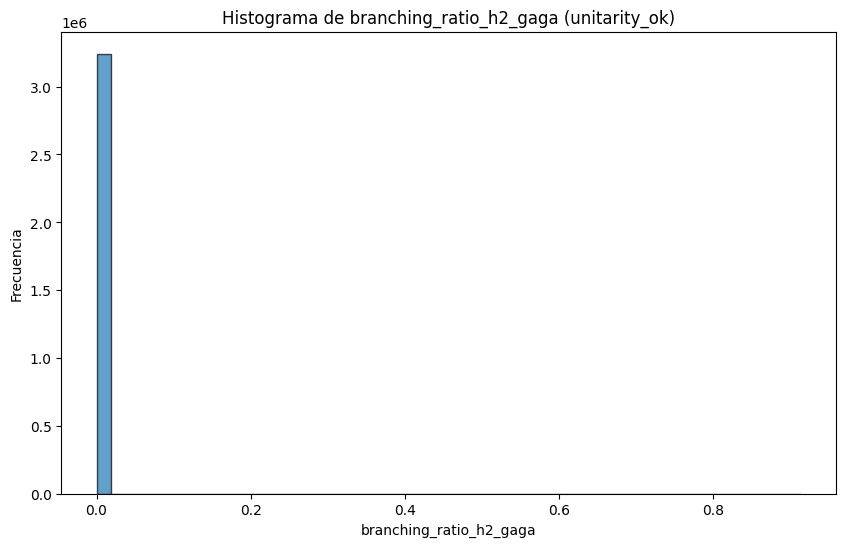

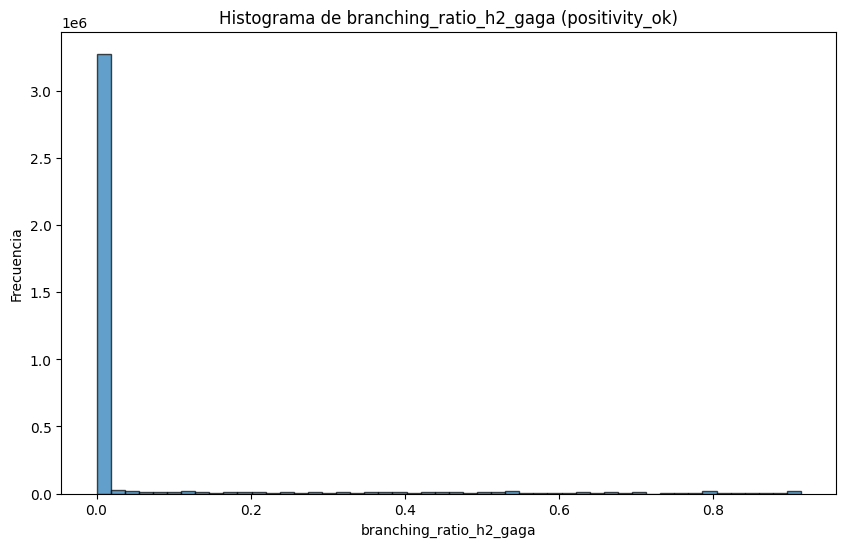

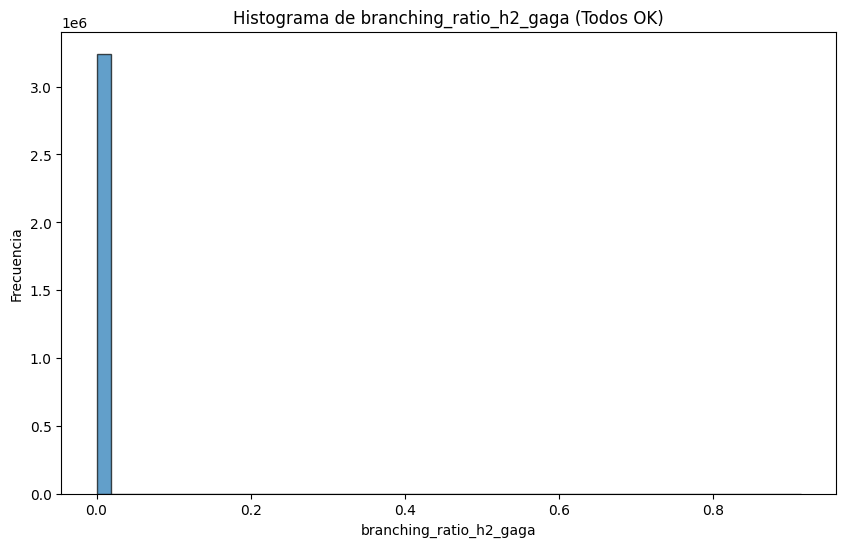

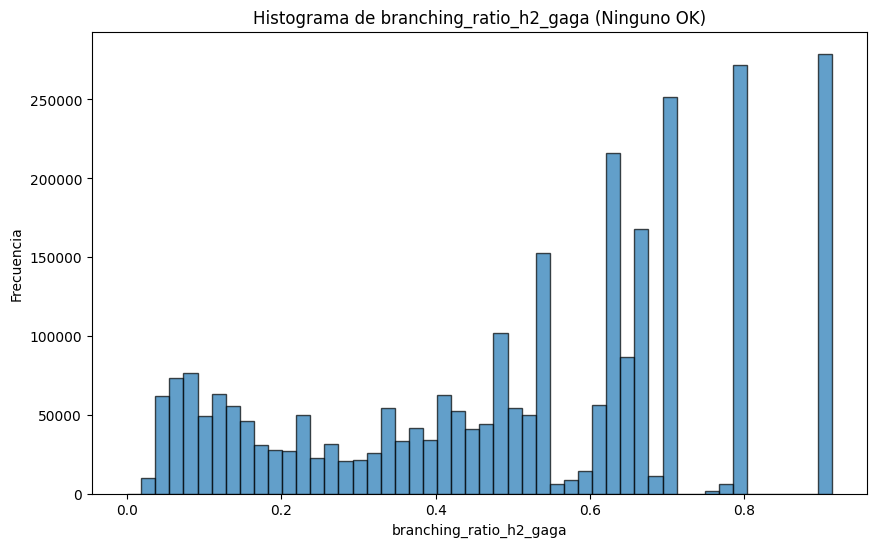

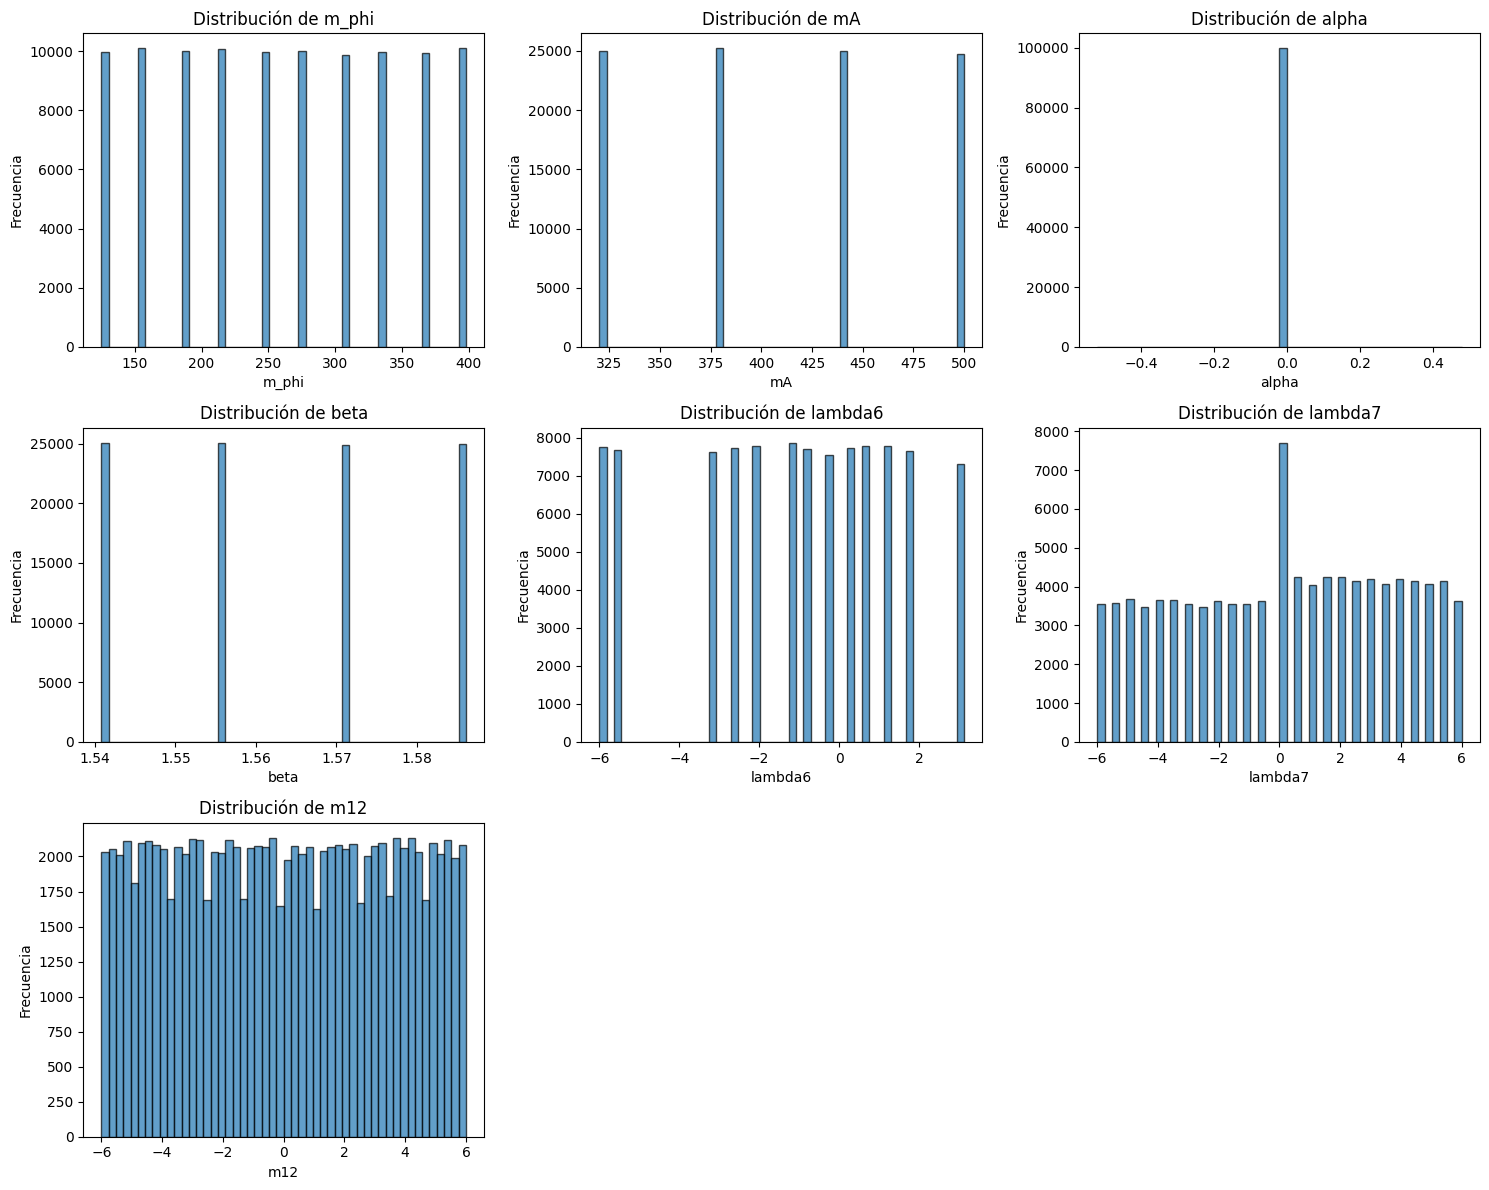

Datos de histogramas guardados en pickle: hist_bins.pkl


In [5]:

# -----------------------
# Parte 4: Graficar distribuciones
# -----------------------

# Función para graficar histograma dado un histograma acumulado y etiquetas
def plot_histogram(hist_counts, bin_edges, title):
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.figure(figsize=(10,6))
    plt.bar(bin_centers, hist_counts, width=(bin_edges[-1]-bin_edges[0])/bins,
            edgecolor='k', alpha=0.7)
    plt.xlabel(target_col)
    plt.ylabel("Frecuencia")
    plt.title(title)
    plt.show()

plot_histogram(hist_dict["all"], bin_edges, "Histograma acumulado de " + target_col + " (Todos los puntos)")
plot_histogram(hist_dict["perturbativity_ok"], bin_edges, "Histograma de " + target_col + " (perturbativity_ok)")
plot_histogram(hist_dict["unitarity_ok"], bin_edges, "Histograma de " + target_col + " (unitarity_ok)")
plot_histogram(hist_dict["positivity_ok"], bin_edges, "Histograma de " + target_col + " (positivity_ok)")
plot_histogram(hist_dict["all_three"], bin_edges, "Histograma de " + target_col + " (Todos OK)")
plot_histogram(hist_dict["none"], bin_edges, "Histograma de " + target_col + " (Ninguno OK)")

# Graficar las distribuciones de los 7 parámetros de la muestra (reservorio)
fig, axs = plt.subplots(3, 3, figsize=(15,12))
axs = axs.flatten()
for i, col in enumerate(param_cols):
    axs[i].hist(sample_df[col], bins=50, edgecolor='k', alpha=0.7)
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")
for j in range(len(param_cols), len(axs)):
    axs[j].axis('off')
plt.tight_layout()
plt.show()

# -----------------------
# Parte 5: Guardar bins en formato pickle
# -----------------------
# Se guarda un diccionario con la siguiente estructura:
# {
#   "group_name": {
#       "bin_edges": np.array([...]),
#       "hist_counts": np.array([...])
#    },
#   ...
# }
bins_data = {}
for key in hist_dict:
    bins_data[key] = {
        "bin_edges": bin_edges,
        "hist_counts": hist_dict[key]
    }

pickle_filename = "hist_bins.pkl"
with open(pickle_filename, "wb") as pkl_file:
    pickle.dump(bins_data, pkl_file)
print("Datos de histogramas guardados en pickle:", pickle_filename)


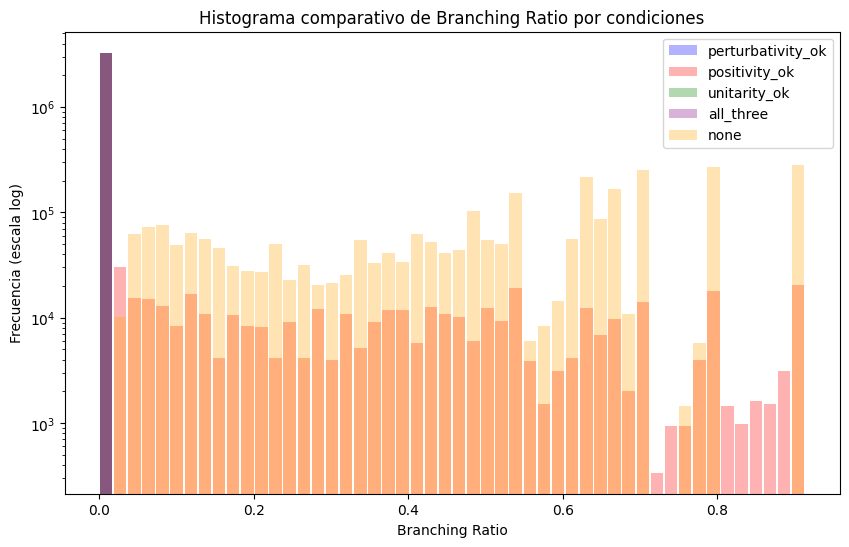

In [6]:
# -----------------------
# Parte 6: Graficar histogramas múltiples con distintos colores y eje y en escala log
import matplotlib.pyplot as plt

def plot_multiple_histograms(bin_edges, hist_dict, groups, colors, alpha=0.6):
    """
    Grafica en un mismo gráfico los histogramas de varios grupos.
    
    Parámetros:
      - bin_edges: array con los bordes de los bins.
      - hist_dict: diccionario con los histogramas acumulados para cada grupo.
      - groups: lista de claves (en hist_dict) que se desean graficar.
      - colors: lista o diccionario de colores para cada grupo.
      - alpha: transparencia para las barras.
    """
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = (bin_edges[-1]-bin_edges[0]) / len(bin_edges) * 0.9  # ancho de barra algo menor que el bin
    plt.figure(figsize=(10,6))
    
    for group in groups:
        # Se obtiene el color para el grupo (si colors es un diccionario)
        color = colors[group] if isinstance(colors, dict) else colors[groups.index(group)]
        plt.bar(bin_centers, hist_dict[group], width=width, color=color, alpha=alpha, 
                label=group, align="center")
    
    plt.xlabel("Branching Ratio")
    plt.ylabel("Frecuencia (escala log)")
    plt.title("Histograma comparativo de Branching Ratio por condiciones")
    plt.yscale("log")
    plt.legend()
    plt.show()

# Definir los grupos que queremos graficar y sus colores
groups_to_plot = ["perturbativity_ok", "positivity_ok", "unitarity_ok", "all_three", "none"]
colors_dict = {
    "perturbativity_ok": "blue",
    "positivity_ok": "red",
    "unitarity_ok": "green",
    "all_three": "purple",
    "none": "orange"
}

# Graficar
plot_multiple_histograms(bin_edges, hist_dict, groups_to_plot, colors_dict, alpha=0.3)


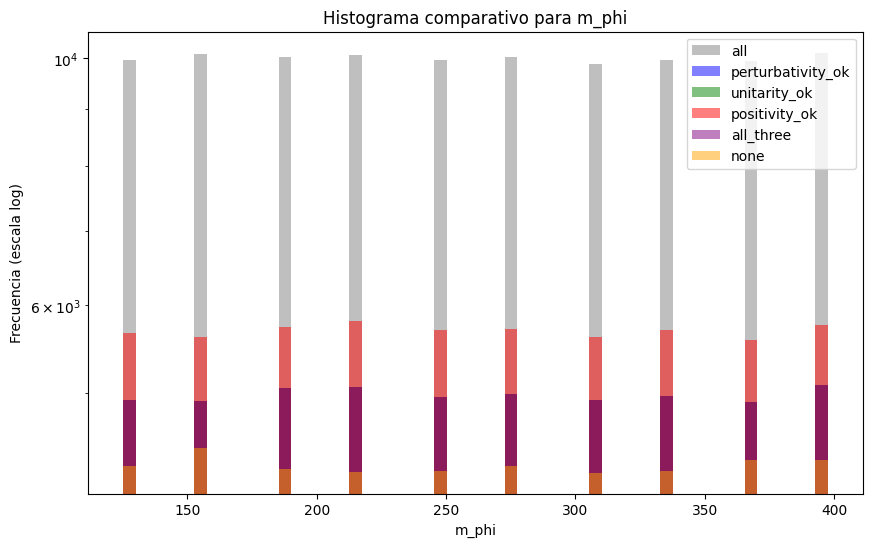

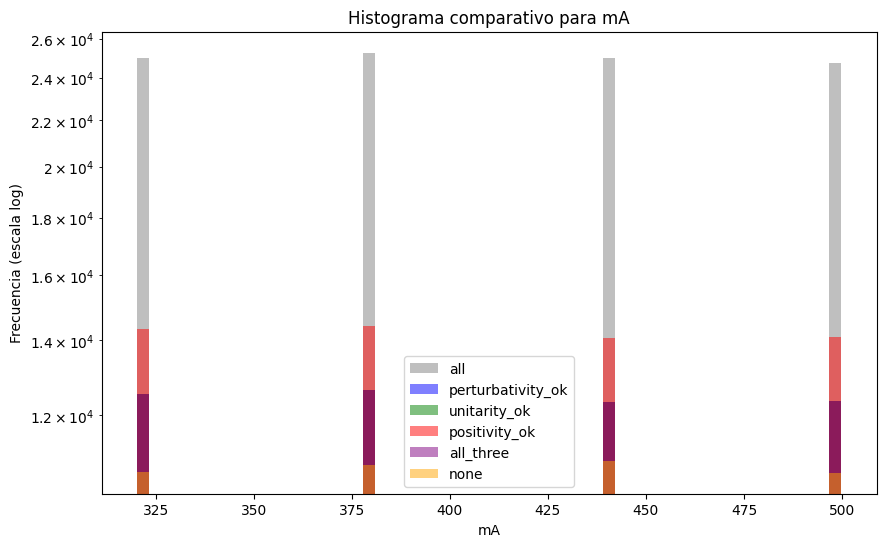

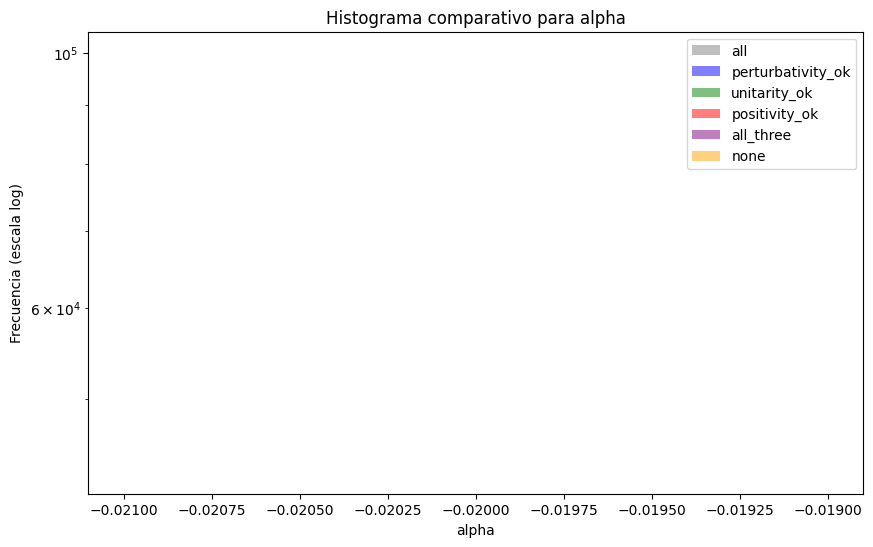

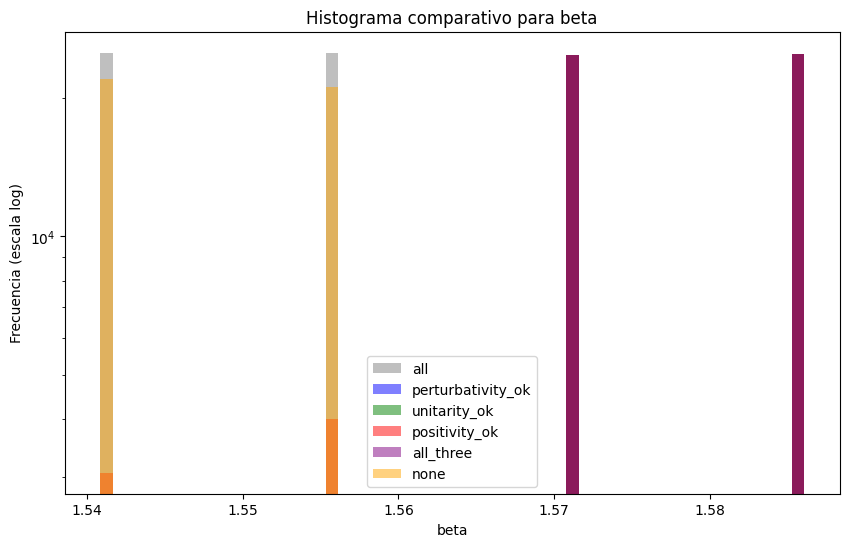

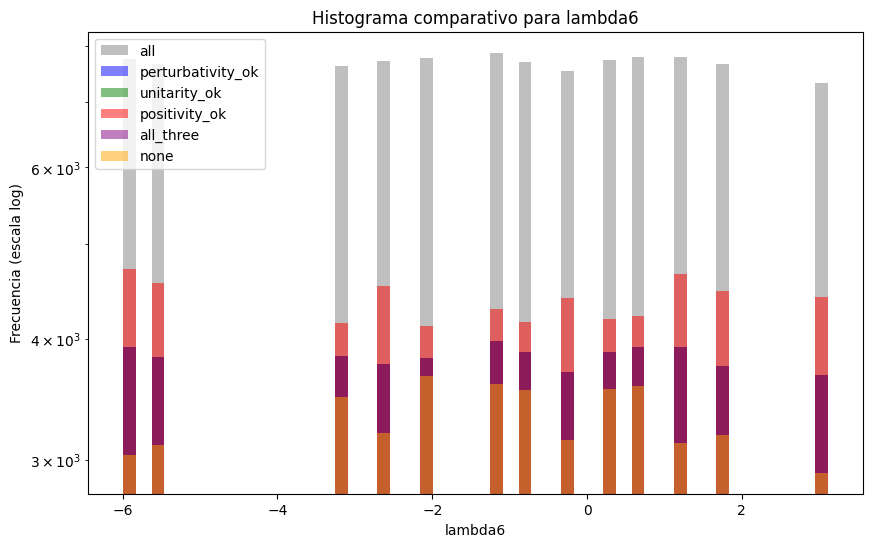

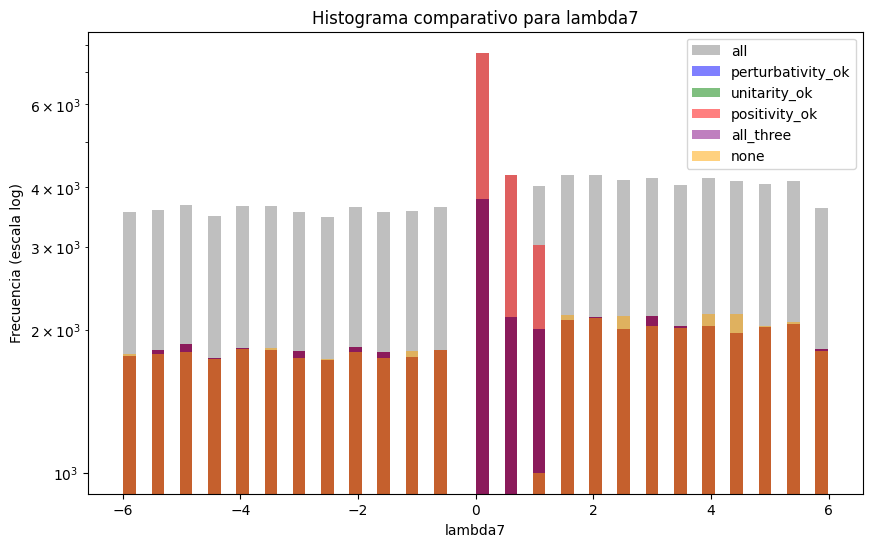

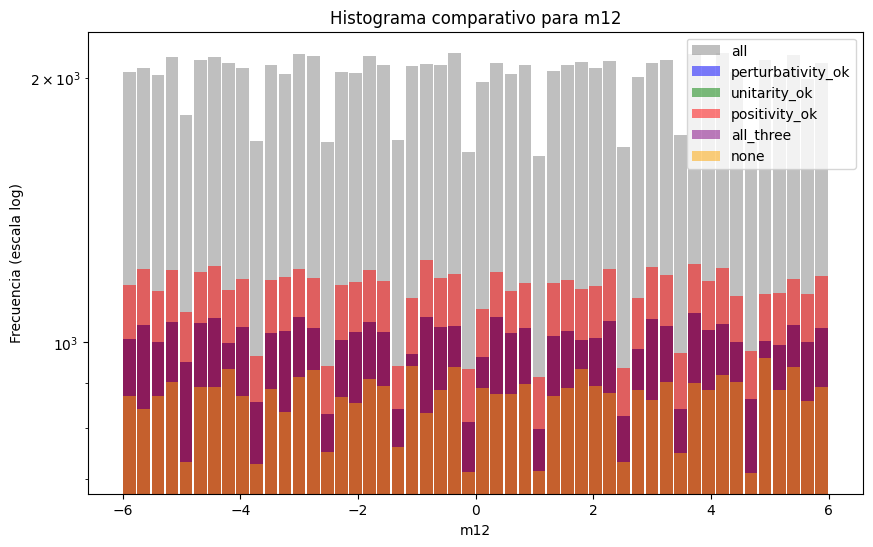

In [7]:
# -----------------------
# Parte 7: Graficar distribuciones para cada parámetro (param_cols)
import matplotlib.pyplot as plt

def plot_param_histograms(param, sample_df, bins=50, colors_dict=None):
    """
    Genera un histograma superpuesto para un parámetro, mostrando:
      - Todos los datos ("all")
      - Datos que cumplen cada condición: "perturbativity_ok", "unitarity_ok", "positivity_ok"
      - Datos que cumplen las tres condiciones ("all_three")
      - Datos que no cumplen ninguna ("none")
    
    Los histogramas se grafican con distinto color, transparencia y eje y en escala logarítmica.
    """
    # Definir colores por defecto si no se proporcionan
    if colors_dict is None:
        colors_dict = {
            "all": "gray",
            "perturbativity_ok": "blue",
            "unitarity_ok": "green",
            "positivity_ok": "red",
            "all_three": "purple",
            "none": "orange"
        }
    
    # Obtener datos válidos para el parámetro
    valid_data = sample_df[param].dropna()
    if valid_data.empty:
        print(f"No hay datos válidos para {param}.")
        return
    
    param_min = valid_data.min()
    param_max = valid_data.max()
    bin_edges = np.linspace(param_min, param_max, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = (bin_edges[1] - bin_edges[0]) * 0.9

    plt.figure(figsize=(10, 6))
    
    # Grupo "all": todos los datos
    all_data = valid_data.values
    counts_all, _ = np.histogram(all_data, bins=bin_edges)
    plt.bar(bin_centers, counts_all, width=width, color=colors_dict["all"], alpha=0.5, label="all", align="center")
    
    # Grupo: perturbativity_ok
    group_data = sample_df[sample_df["perturbativity_ok"] == 1][param].dropna().values
    if len(group_data) > 0:
        counts, _ = np.histogram(group_data, bins=bin_edges)
        plt.bar(bin_centers, counts, width=width, color=colors_dict["perturbativity_ok"], alpha=0.5, label="perturbativity_ok", align="center")
    
    # Grupo: unitarity_ok
    group_data = sample_df[sample_df["unitarity_ok"] == 1][param].dropna().values
    if len(group_data) > 0:
        counts, _ = np.histogram(group_data, bins=bin_edges)
        plt.bar(bin_centers, counts, width=width, color=colors_dict["unitarity_ok"], alpha=0.5, label="unitarity_ok", align="center")
    
    # Grupo: positivity_ok
    group_data = sample_df[sample_df["positivity_ok"] == 1][param].dropna().values
    if len(group_data) > 0:
        counts, _ = np.histogram(group_data, bins=bin_edges)
        plt.bar(bin_centers, counts, width=width, color=colors_dict["positivity_ok"], alpha=0.5, label="positivity_ok", align="center")
    
    # Grupo: all_three (los tres OK)
    group_data = sample_df[(sample_df["perturbativity_ok"] == 1) & 
                           (sample_df["unitarity_ok"] == 1) & 
                           (sample_df["positivity_ok"] == 1)][param].dropna().values
    if len(group_data) > 0:
        counts, _ = np.histogram(group_data, bins=bin_edges)
        plt.bar(bin_centers, counts, width=width, color=colors_dict["all_three"], alpha=0.5, label="all_three", align="center")
    
    # Grupo: none (ninguna OK)
    group_data = sample_df[(sample_df["perturbativity_ok"] == 0) & 
                           (sample_df["unitarity_ok"] == 0) & 
                           (sample_df["positivity_ok"] == 0)][param].dropna().values
    if len(group_data) > 0:
        counts, _ = np.histogram(group_data, bins=bin_edges)
        plt.bar(bin_centers, counts, width=width, color=colors_dict["none"], alpha=0.5, label="none", align="center")
    
    plt.xlabel(param)
    plt.ylabel("Frecuencia (escala log)")
    plt.title(f"Histograma comparativo para {param}")
    plt.yscale("log")
    plt.legend()
    plt.show()

# Iterar sobre cada parámetro en param_cols y graficar su distribución
for col in param_cols:
    plot_param_histograms(col, sample_df, bins=50)
